<a href="https://colab.research.google.com/github/Kdshah1512/Academics-projects/blob/main/bigdata_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title : google play store review**

Problem statement: this is machine learning based project that includes sentiment analysis of review provided by users in play store for understanding how users think about different apps.the reviews and sentiments are included in the dataset: postive,negetive and neutral.reviews should be classified, based on machine learning and deep learning models, into their respective sentiment categories for further understanding of user satisfaction, scope of improvement, and generalized feedback regarding apps.






link: https://www.kaggle.com/code/isha21/starter-google-play-store-apps-27687a93-3/input?select=googleplaystore_user_reviews.csv

importing necesssary libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from wordcloud import WordCloud
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.utils import to_categorical


df = pd.read_csv('play store.csv', on_bad_lines='skip')


print("Original DataFrame:")
print(df.head())

cleaned_df = df.dropna()
print(cleaned_df)


Original DataFrame:
                                                 App  \
0  10 Best Foods for You,"I like eat delicious fo...   
1                              10 Best Foods for You   
2                              10 Best Foods for You   
3                              10 Best Foods for You   
4                              10 Best Foods for You   

                                 Translated_Review Sentiment  \
0                                              NaN       NaN   
1  This help eating healthy exercise regular basis  Positive   
2                                              NaN       NaN   
3       Works great especially going grocery store  Positive   
4                                     Best idea us  Positive   

  Sentiment_Polarity Sentiment_Subjectivity;;;;  
0                NaN                        NaN  
1               0.25    0.28846153846153844;;;;  
2                NaN                    nan;;;;  
3                0.4                  0.875;;;;  
4       

Feature Engineering


Sentiment Distribution (after cleaning):


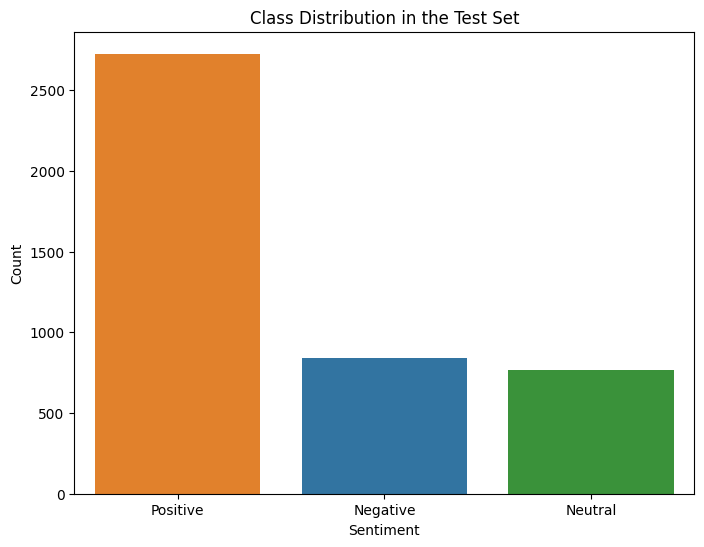

In [ ]:

df.columns = df.columns.str.replace(';;;;', '').str.strip()
df.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)

df = df[df['Sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

print("\nSentiment Distribution (after cleaning):")
sentiment_counts = df['Sentiment'].value_counts()
X = df['Translated_Review']
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(8, 6))
sns.countplot(x=y_test, order=y_test.value_counts().index, hue=y_test, dodge=False, legend=False)
plt.title("Class Distribution in the Test Set")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()



split the data

In [ ]:



X = df['Translated_Review']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)


Shape of X_train: (17333,)
Shape of X_test: (4334,)


text vectorization - TF-IDF

In [ ]:



vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)


Shape of X_train_tfidf: (17333, 2000)
Shape of X_test_tfidf: (4334, 2000)


This code use for the TFIDF vectorizer to convert textdata to numerical form.

use SMOTE to handle class imbalance

In [ ]:



smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_tfidf, y_train)


print("\nClass distribution after SMOTE:")
print(pd.Series(y_res).value_counts())



/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



Class distribution after SMOTE:
Sentiment
Positive    10779
Neutral     10779
Negative    10779
Name: count, dtype: int64


SMOTE calculate synthetic sample for minority class to introduce existing sample.

# **Traditional Models evalution**

naive bayes model


Naive Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.81      0.64       842
     Neutral       0.64      0.62      0.63       765
    Positive       0.92      0.78      0.85      2727

    accuracy                           0.76      4334
   macro avg       0.70      0.74      0.71      4334
weighted avg       0.80      0.76      0.77      4334



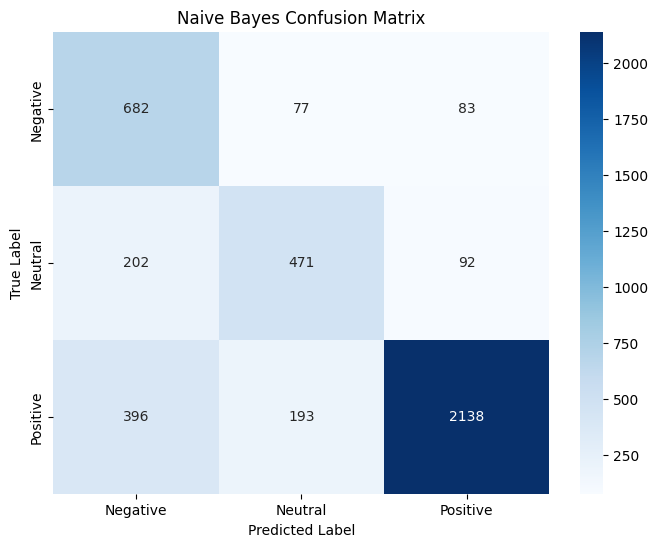

In [ ]:


nb_model = MultinomialNB()
nb_model.fit(X_res, y_res)


from sklearn.metrics import classification_report
y_pred_nb = nb_model.predict(X_test_tfidf)
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Logistic Regression model


Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.86      0.80       842
     Neutral       0.76      0.87      0.81       765
    Positive       0.96      0.87      0.91      2727

    accuracy                           0.87      4334
   macro avg       0.82      0.87      0.84      4334
weighted avg       0.88      0.87      0.87      4334



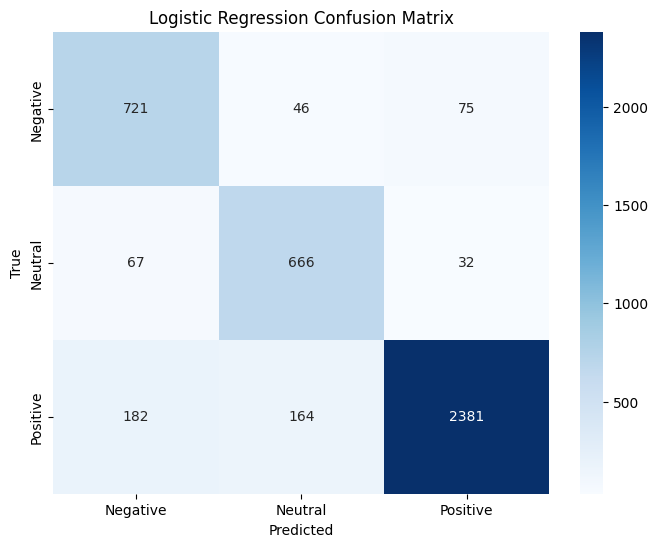

In [ ]:

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_res, y_res)


y_pred_lr = lr_model.predict(X_test_tfidf)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


SVM model


SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.79      0.83       842
     Neutral       0.83      0.87      0.85       765
    Positive       0.92      0.93      0.93      2727

    accuracy                           0.90      4334
   macro avg       0.87      0.87      0.87      4334
weighted avg       0.90      0.90      0.89      4334



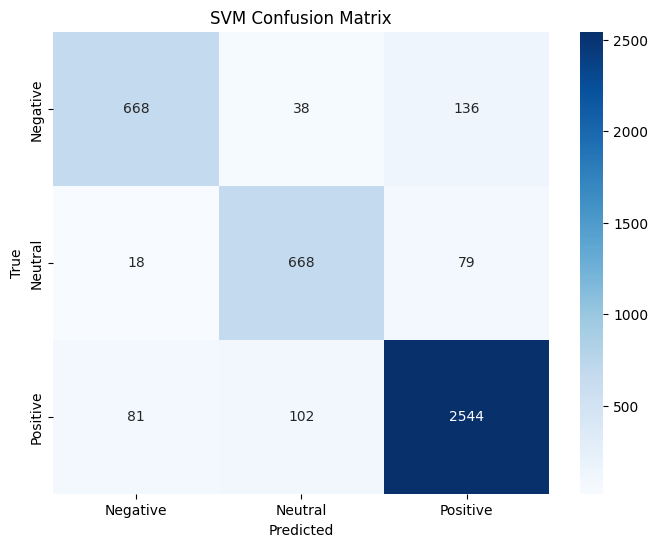

In [ ]:

svm_model = SVC(kernel='linear', random_state=42)


vectorizer_svm = TfidfVectorizer(stop_words='english', max_features=2000)
X_train_tfidf_svm = vectorizer_svm.fit_transform(X_train)
X_test_tfidf_svm = vectorizer_svm.transform(X_test)

svm_model.fit(X_train_tfidf_svm, y_train)


y_pred_svm = svm_model.predict(X_test_tfidf_svm)
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
svm_accuracy = accuracy_score(y_test, y_pred_svm)


model_accuracies = {
    "Naive Bayes": nb_accuracy,
    "Logistic Regression": lr_accuracy,
    "SVM": svm_accuracy
}


best_model = max(model_accuracies, key=model_accuracies.get)


print(f"The best performing model is: {best_model} with an accuracy of {model_accuracies[best_model]:.4f}")

The best performing model is: SVM with an accuracy of 0.8952


The code calculates three model accuracies and the best model is SVM which is provides highest accuracy (0.89)

Deep learning model

In [ ]:



vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X_train_tfidf = vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = vectorizer.transform(X_test).toarray()


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_train_categorical = to_categorical(y_train_encoded)
y_test_categorical = to_categorical(y_test_encoded)


inputs = layers.Input(shape=(X_train_tfidf.shape[1],))
embedding = layers.Embedding(input_dim=500, output_dim=64)(inputs)
attention = layers.MultiHeadAttention(num_heads=2, key_dim=64)(embedding, embedding)
pooling = layers.GlobalAveragePooling1D()(attention)
dropout = layers.Dropout(0.1)(pooling)
dense = layers.Dense(64, activation='relu')(dropout)
outputs = layers.Dense(3, activation='softmax')(dense)


model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)


model.fit(X_train_tfidf, y_train_categorical, epochs=3, batch_size=32, validation_data=(X_test_tfidf, y_test_categorical), callbacks=[early_stopping])


test_loss, test_accuracy = model.evaluate(X_test_tfidf, y_test_categorical)
print(f"Test Accuracy: {test_accuracy:.4f}")




Epoch 1/3
542/542 ━━━━━━━━━━━━━━━━━━━━ 443s 804ms/step - accuracy: 0.6117 - loss: 0.9423 - val_accuracy: 0.6292 - val_loss: 0.9180
Epoch 2/3
542/542 ━━━━━━━━━━━━━━━━━━━━ 416s 768ms/step - accuracy: 0.6168 - loss: 0.9323 - val_accuracy: 0.6292 - val_loss: 0.9167
Epoch 3/3
542/542 ━━━━━━━━━━━━━━━━━━━━ 407s 703ms/step - accuracy: 0.6253 - loss: 0.9223 - val_accuracy: 0.6292 - val_loss: 0.9200
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 277ms/step - accuracy: 0.6218 - loss: 0.9250
Test Accuracy: 0.6292


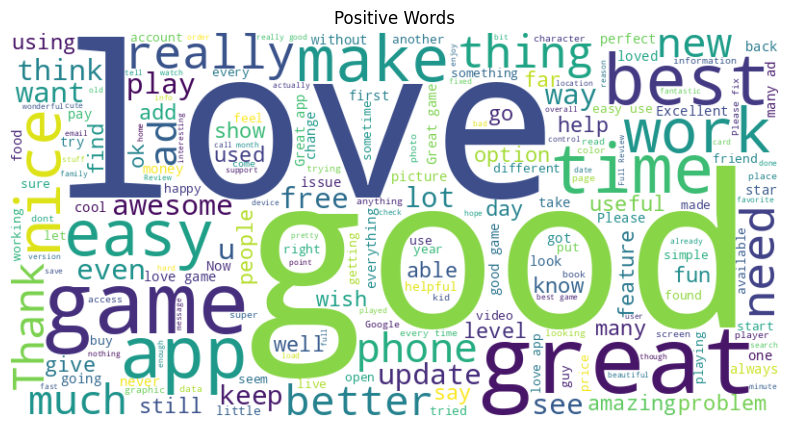

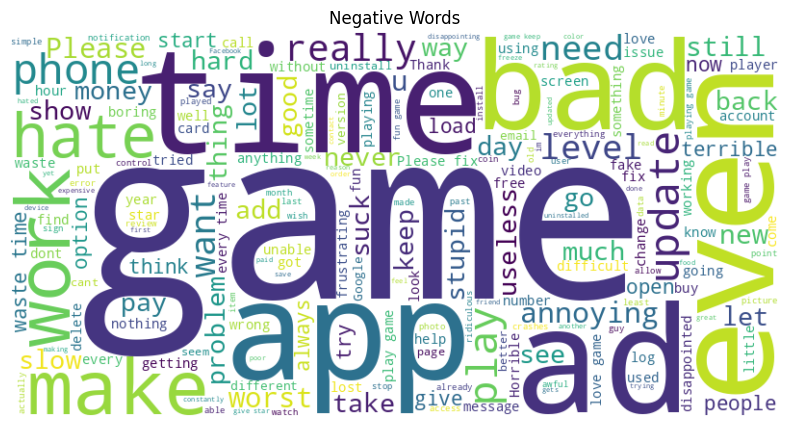

In [ ]:



positive_words = ' '.join(df[df['Sentiment'] == 'Positive']['Translated_Review'].astype(str))
negative_words = ' '.join(df[df['Sentiment'] == 'Negative']['Translated_Review'].astype(str))



wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Words')
plt.show()



wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Negative Words')
plt.show()

This code in showning the most postive and negetive words for sentiment review of google play store

## **Conclusion**  

This project deals with the sentiment analysis of review of google play store using both traditional machine learning  and deep learning model.after applying SMOTE for handling class imbalance so dataset sentiment distribution was balanced .The textual data was succesfully transformed to numeric data using TF-IDF vectorization to show underlying trends in reviews .Among the all traditional models the best model is SVM (support vector nachine) which is give highest accuracy (0.8952).a deep learning model with an embedding layer, multi-head attention, and dense layers that showed competitive accuracy of 0.6292